In [1]:
import matplotlib.pyplot as plt

In [10]:
import torch
from torch.utils.data import DataLoader

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.13.0+cu126
CUDA available: True
CUDA version: 12.6
GPU count: 1
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

In [5]:
datasets.ImageFolder("E:\Codes\Projects\Crop-disease-detection\Training\PlantVillage")

Dataset ImageFolder
    Number of datapoints: 2152
    Root location: E:\Codes\Projects\Crop-disease-detection\Training\PlantVillage

In [12]:
DATA_DIR = "E:\Codes\Projects\Crop-disease-detection\Training\PlantVillage"

In [13]:
IMAGE_SIZE = 256

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

In [14]:
full_dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=train_transform
)

print("Total images:", len(full_dataset))
print("Classes:", full_dataset.classes)
print("Class mapping:", full_dataset.class_to_idx)

Total images: 2152
Classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Class mapping: {'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}


In [15]:
total_size = len(full_dataset)

train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Testing:", len(test_dataset))

Training: 1721
Validation: 215
Testing: 216


In [17]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [18]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

Images shape: torch.Size([32, 3, 256, 256])
Labels shape: torch.Size([32])
Labels: tensor([0, 1, 2, 1, 1, 2, 1, 1, 0, 2])


In [20]:
base_dataset = datasets.ImageFolder(
    root=DATA_DIR
)

train_size = int(0.8 * len(base_dataset))
val_size = int(0.1 * len(base_dataset))
test_size = len(base_dataset) - train_size - val_size

indices = torch.randperm(
    len(base_dataset),
    generator=torch.Generator().manual_seed(42)
).tolist()

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

In [21]:
train_full = datasets.ImageFolder(
    root=DATA_DIR,
    transform=train_transform
)

test_full = datasets.ImageFolder(
    root=DATA_DIR,
    transform=test_transform
)

In [22]:
from torch.utils.data import Subset

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(test_full, val_indices)
test_dataset = Subset(test_full, test_indices)

In [23]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [24]:
class_names = train_full.classes

print(class_names)
print("Number of classes:", len(class_names))

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Number of classes: 3


In [25]:
import torch.nn as nn

class PlantDiseaseCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 4 * 4, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [26]:
num_classes = len(class_names)

model = PlantDiseaseCNN(num_classes)

print(model)

PlantDiseaseCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  

In [28]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [29]:
images, labels = next(iter(train_loader))

In [30]:
images = images.to(device)
labels = labels.to(device)

In [31]:
outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 256, 256])
Output shape: torch.Size([32, 3])


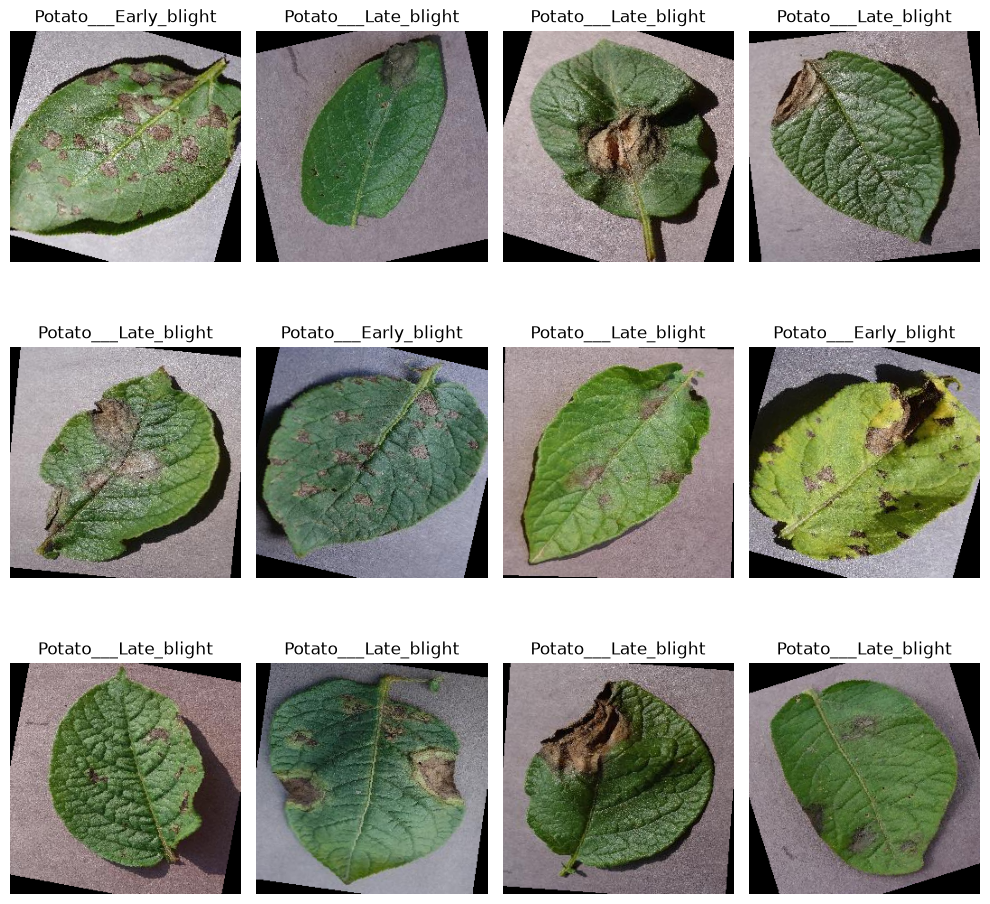

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

images, labels = next(iter(train_loader))

for i in range(12):
    ax = plt.subplot(3, 4, i + 1)

    # PyTorch image: [C, H, W]
    # Matplotlib expects: [H, W, C]
    image = images[i].permute(1, 2, 0)

    plt.imshow(image)

    # Convert label tensor to integer
    plt.title(class_names[labels[i].item()])

    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
EPOCHS = 50

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total


    # -------------------------
    # Validation
    # -------------------------

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_accuracy = 100 * correct / total


    # Store metrics

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/50] Train Loss: 0.9650 Train Acc: 47.30% Val Loss: 0.9225 Val Acc: 46.05%
Epoch [2/50] Train Loss: 0.8993 Train Acc: 50.73% Val Loss: 0.8661 Val Acc: 53.95%
Epoch [3/50] Train Loss: 0.6293 Train Acc: 76.70% Val Loss: 0.4759 Val Acc: 83.72%
Epoch [4/50] Train Loss: 0.4694 Train Acc: 82.68% Val Loss: 0.4096 Val Acc: 84.65%
Epoch [5/50] Train Loss: 0.3878 Train Acc: 85.36% Val Loss: 0.4427 Val Acc: 83.26%
Epoch [6/50] Train Loss: 0.3942 Train Acc: 84.43% Val Loss: 0.3562 Val Acc: 86.05%
Epoch [7/50] Train Loss: 0.3085 Train Acc: 87.80% Val Loss: 0.2119 Val Acc: 93.95%
Epoch [8/50] Train Loss: 0.2445 Train Acc: 91.63% Val Loss: 0.4147 Val Acc: 86.51%
Epoch [9/50] Train Loss: 0.1989 Train Acc: 93.03% Val Loss: 0.1634 Val Acc: 93.02%
Epoch [10/50] Train Loss: 0.1667 Train Acc: 94.13% Val Loss: 0.1829 Val Acc: 94.42%
Epoch [11/50] Train Loss: 0.1761 Train Acc: 93.49% Val Loss: 0.2802 Val Acc: 87.91%
Epoch [12/50] Train Loss: 0.1703 Train Acc: 93.78% Val Loss: 0.0563 Val Acc: 99.07%
E

In [36]:
model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_loss = test_loss / len(test_loader)
test_accuracy = 100 * correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.0190
Test Accuracy: 99.54%


In [37]:
from sklearn.metrics import classification_report

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.cpu().numpy())

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names
    )
)

                       precision    recall  f1-score   support

Potato___Early_blight       1.00      0.99      1.00       111
 Potato___Late_blight       0.99      1.00      0.99        93
     Potato___healthy       1.00      1.00      1.00        12

             accuracy                           1.00       216
            macro avg       1.00      1.00      1.00       216
         weighted avg       1.00      1.00      1.00       216



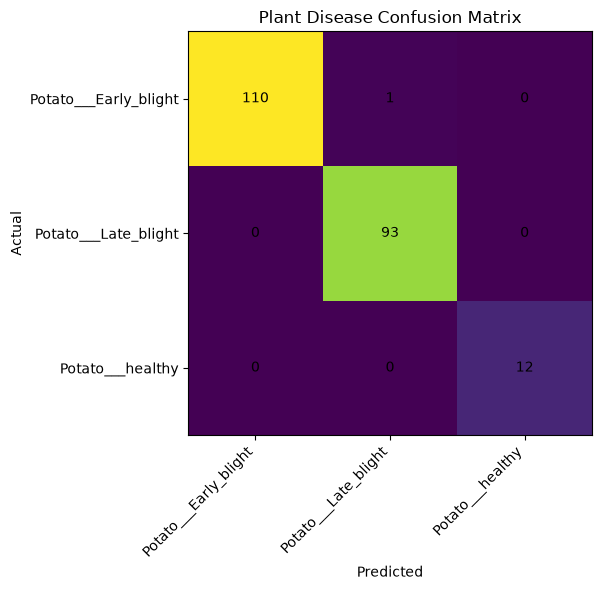

In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("Plant Disease Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

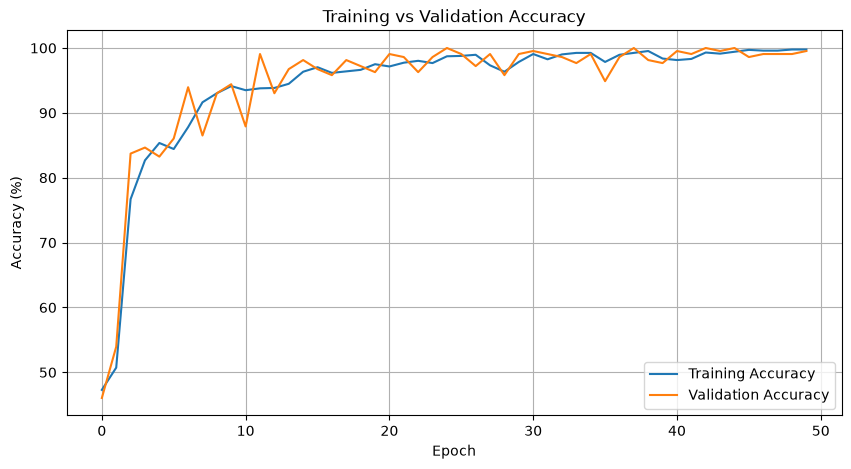

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()
plt.show()

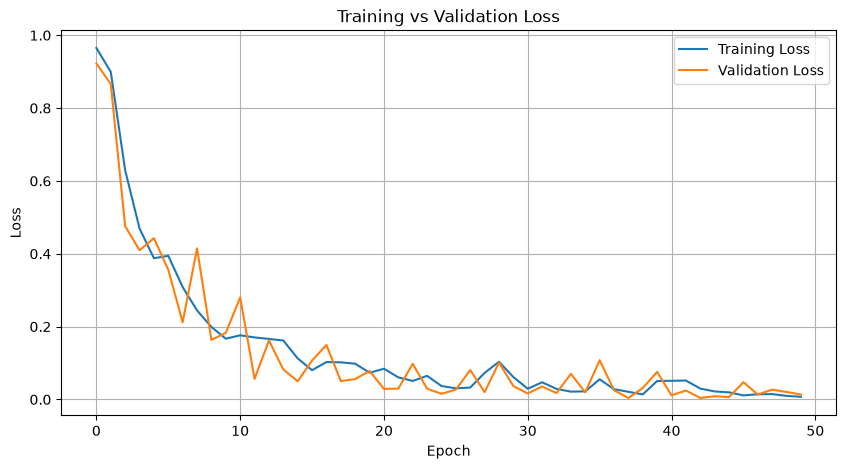

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()
plt.show()

In [41]:
torch.save(
    model.state_dict(),
    "plant_disease.pth"
)

In [42]:
import os

print(
    "Model saved:",
    os.path.exists("plant_disease.pth")
)

Model saved: True


In [43]:
import json

with open("classes.json", "w") as f:
    json.dump(class_names, f)

print(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [47]:
from PIL import Image

image_path = r"E:\Codes\Projects\Crop-disease-detection\Training\PlantVillage\Potato___Early_blight\0c4f6f72-c7a2-42e1-9671-41ab3bf37fe7___RS_Early.B 6752.JPG"

image = Image.open(image_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

image_tensor = transform(image)

image_tensor = image_tensor.unsqueeze(0)

image_tensor = image_tensor.to(device)

model.eval()

with torch.no_grad():

    output = model(image_tensor)

    probabilities = torch.softmax(output, dim=1)

    confidence, predicted = torch.max(
        probabilities,
        1
    )

predicted_class = class_names[predicted.item()]

print("Prediction:", predicted_class)
print(
    "Confidence:",
    f"{confidence.item() * 100:.2f}%"
)

Prediction: Potato___Early_blight
Confidence: 100.00%


In [48]:
model.eval()

PlantDiseaseCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  

In [49]:
dummy_input = torch.randn(
    1,
    3,
    256,
    256,
    device=device
)

In [51]:
torch.onnx.export(
    model,
    dummy_input,
    "plant_disease.onnx",
    input_names=["image"],
    output_names=["output"],
    dynamic_axes={
        "image": {0: "batch_size"},
        "output": {0: "batch_size"}
    },
    opset_version=17
)

print("ONNX model exported successfully!")

C:\Users\Nitish\AppData\Local\Temp\ipykernel_3864\837573970.py:1: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0926 22:12:39.837000 3864 site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `PlantDiseaseCNN([...]` with `torch.export.export(..., strict=False)`...


W0926 22:12:41.066000 3864 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


[torch.onnx] Obtain model graph for `PlantDiseaseCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Users\Nitish\AppData\Local\Programs\Python\Python311\Lib\copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX model exported successfully!


In [52]:
import onnxruntime as ort

session = ort.InferenceSession(
    "plant_disease.onnx",
    providers=["CPUExecutionProvider"]
)

print("ONNX model loaded successfully!")

ONNX model loaded successfully!


In [53]:
input_name = session.get_inputs()[0].name

print("Input name:", input_name)

Input name: image


In [54]:
import numpy as np

onnx_input = image_tensor.cpu().numpy()

onnx_output = session.run(
    None,
    {
        input_name: onnx_input
    }
)

print(onnx_output)

[array([[ 31.144705 ,   1.8103775, -45.625896 ]], dtype=float32)]


In [55]:
onnx_prediction = np.argmax(
    onnx_output[0],
    axis=1
)[0]

print(
    "ONNX Prediction:",
    class_names[onnx_prediction]
)

ONNX Prediction: Potato___Early_blight
